# Physical Resource And QEC Estimators

This notebook teaches the input/output shape of physical resource estimation without pretending to run a full estimator unless the sandbox is present.

Corpus anchors: `PRIM4`, `PRIM6`, `PRIM13`, `QRE2`, `QRE4`, `IO4`, `IO5`, `IO7`, `IO8`.

Compact object: toy logical counts mapped through an explicitly fake surface-code scaling curve.


tooling atlas output directory: .cache\tooling_atlas


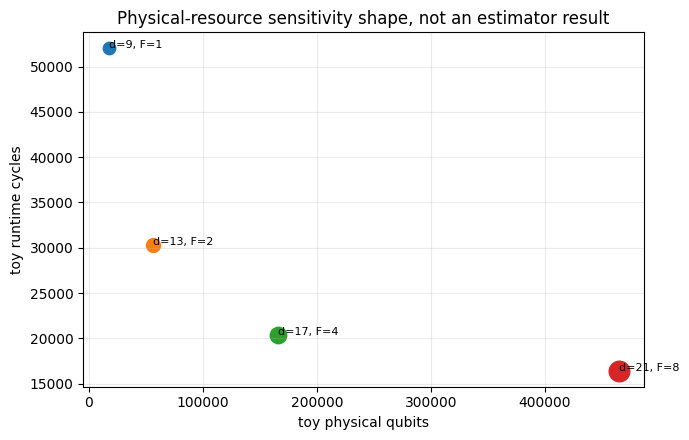

falsifiable check: this toy model exposes a qubit/runtime tradeoff as factories increase


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

logical_counts = {
    'numQubits': 47,
    'tCount': 47_500,
    'rotationCount': 2_000,
    'rotationDepth': 500,
    'cczCount': 0,
    'measurementCount': 1_000,
}

def toy_physical_estimate(distance: int, factories: int) -> dict[str, float]:
    algorithm_qubits = logical_counts['numQubits'] * 2 * distance * distance
    factory_qubits = factories * 120 * distance * distance
    runtime_cycles = logical_counts['tCount'] / max(factories, 1) + logical_counts['rotationDepth'] * distance
    return {
        'distance': distance,
        'factories': factories,
        'physical_qubits': algorithm_qubits + factory_qubits,
        'runtime_cycles': runtime_cycles,
    }

estimates = [toy_physical_estimate(d, f) for d, f in [(9, 1), (13, 2), (17, 4), (21, 8)]]
fig, ax = plt.subplots(figsize=(7, 4.5))
for row in estimates:
    ax.scatter(row['physical_qubits'], row['runtime_cycles'], s=60 + 20 * row['factories'])
    ax.text(row['physical_qubits'], row['runtime_cycles'], f"d={row['distance']}, F={row['factories']}", fontsize=8)
ax.set_xlabel('toy physical qubits')
ax.set_ylabel('toy runtime cycles')
ax.set_title('Physical-resource sensitivity shape, not an estimator result')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

assert all(estimates[i]['physical_qubits'] < estimates[i + 1]['physical_qubits'] for i in range(len(estimates) - 1))
assert estimates[-1]['runtime_cycles'] < estimates[0]['runtime_cycles']
print('falsifiable check: this toy model exposes a qubit/runtime tradeoff as factories increase')


In [2]:
# Sandbox package inventory: generated from .cache/tooling_atlas/installed_packages_report.json.
from pathlib import Path
import json

report_path = Path('.cache/tooling_atlas/installed_packages_report.json')
if report_path.exists():
    report = json.loads(report_path.read_text(encoding='utf-8'))
    rows = []
    for env_name, env in report.items():
        for package, info in env['packages'].items():
            rows.append({
                'env': env_name,
                'package': package,
                'version': info.get('version') or '',
                'import': 'ok' if info.get('import_ok') else 'blocked',
                'note': info.get('error') or '',
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(f"{row['env']:12s} {row['package']:16s} {row['version']:10s} {row['import']:8s} {row['note']}")
else:
    print('No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.')

No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.


In [3]:
# Optional estimator/QEC package checks.
for package in ['qdk', 'qsharp', 'stim', 'sinter', 'pymatching', 'benchq']:
    print(f'{package} installed:', has_module(package))

if has_module('qdk.estimator') or has_module('qsharp.estimator'):
    print('Azure/Microsoft QRE sandbox appears available; a future cell can call LogicalCounts.estimate().')
else:
    print('Azure/Microsoft QRE not installed here. Use a sandbox before trusting API details.')


qdk installed: True
qsharp installed: True
stim installed: False
sinter installed: False
pymatching installed: False
benchq installed: False


Azure/Microsoft QRE sandbox appears available; a future cell can call LogicalCounts.estimate().


## What This Cannot Prove

The plotted curve is deliberately fake. It teaches estimator inputs and tradeoff shape only. Real physical estimates require an actual estimator, target parameters, error budget, logical layout, T-factory assumptions, and route-grounded logical counts.
